In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

df = pd.read_csv(r"C:\Users\deepj\Documents\statistical-analysis-hypothesis-testing\data\processed\ecommerce_cleaned.csv")
print(df.shape)
df.head()

(350, 11)


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


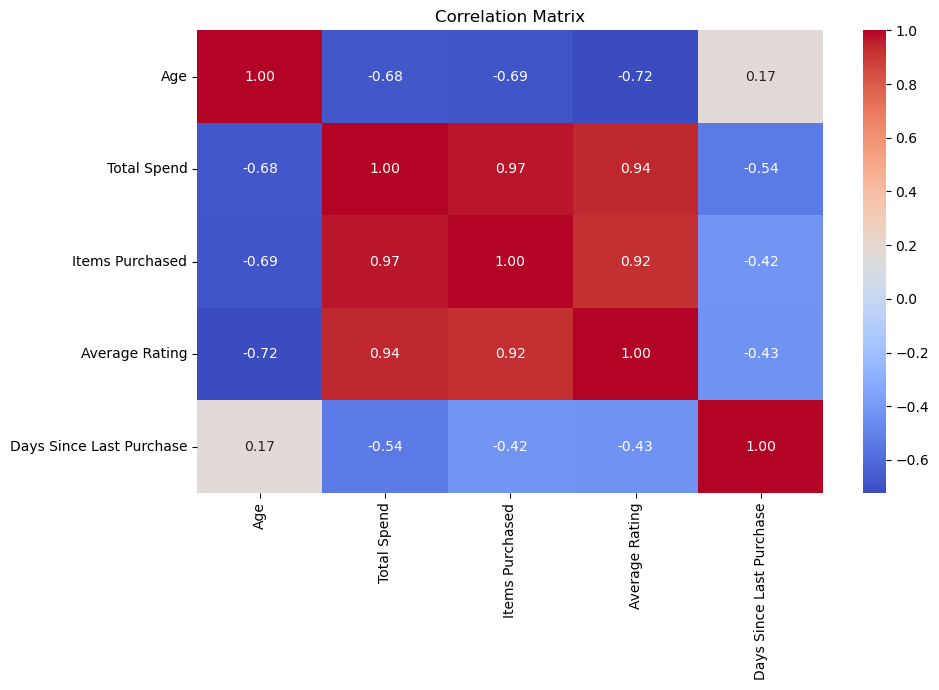

In [2]:
numeric_cols = df[["Age", "Total Spend", "Items Purchased", "Average Rating", "Days Since Last Purchase"]]
corr_matrix = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.savefig(r"C:\Users\deepj\Documents\statistical-analysis-hypothesis-testing\reports\correlation_matrix.png")
plt.show()

In [3]:
x = df[["Items Purchased"]]
y = df["Total Spend"]

model = LinearRegression()
model.fit(x, y)

r_squared = round(model.score(x, y), 4)
coefficient = round(model.coef_[0], 2)

print(f"R-Squared: {r_squared}")
print(f"Coefficient: {coefficient}")
print(f"Every additional item purchased adds ${coefficient} to total spend")

R-Squared: 0.9456
Coefficient: 84.72
Every additional item purchased adds $84.72 to total spend


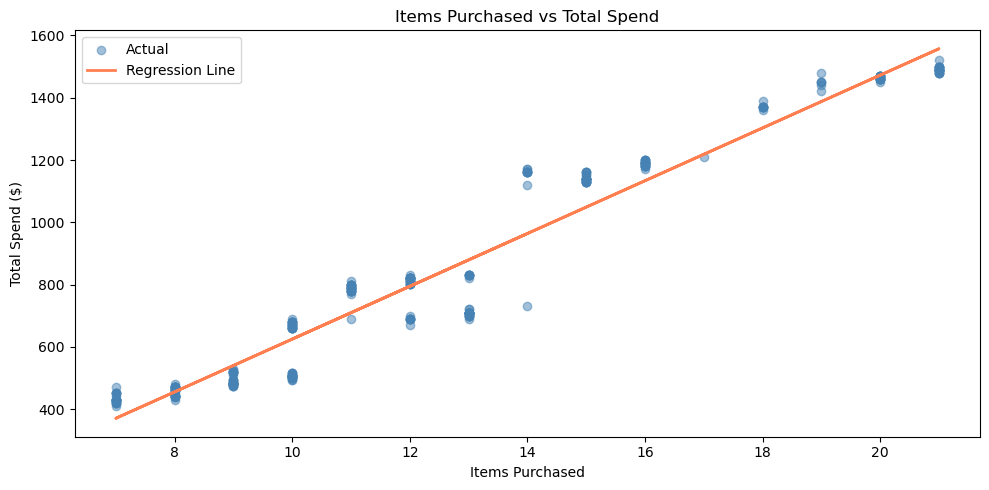

In [4]:
predicted = model.predict(x)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df["Items Purchased"], df["Total Spend"], color="steelblue", alpha=0.5, label="Actual")
ax.plot(df["Items Purchased"], predicted, color="coral", linewidth=2, label="Regression Line")
ax.set(title="Items Purchased vs Total Spend", xlabel="Items Purchased", ylabel="Total Spend ($)")
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\deepj\Documents\statistical-analysis-hypothesis-testing\reports\regression_items_spend.png")
plt.show()

In [5]:
x2 = df[["Age"]]
model2 = LinearRegression()
model2.fit(x2, y)

r_squared2 = round(model2.score(x2, y), 4)
print(f"Age vs Spend R-Squared: {r_squared2}")
print(f"Age Coefficient: {round(model2.coef_[0], 2)}")

Age vs Spend R-Squared: 0.4596
Age Coefficient: -50.39


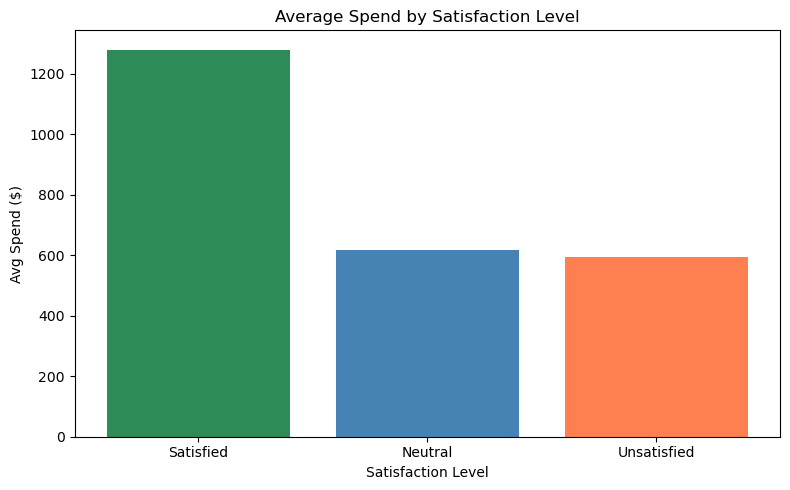

In [6]:
satisfaction_spend = df.groupby("Satisfaction Level")["Total Spend"].mean().reset_index()
satisfaction_spend = satisfaction_spend.sort_values("Total Spend", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(satisfaction_spend["Satisfaction Level"], satisfaction_spend["Total Spend"], color=["seagreen", "steelblue", "coral"])
ax.set(title="Average Spend by Satisfaction Level", xlabel="Satisfaction Level", ylabel="Avg Spend ($)")
plt.tight_layout()
plt.savefig(r"C:\Users\deepj\Documents\statistical-analysis-hypothesis-testing\reports\spend_by_satisfaction.png")
plt.show()

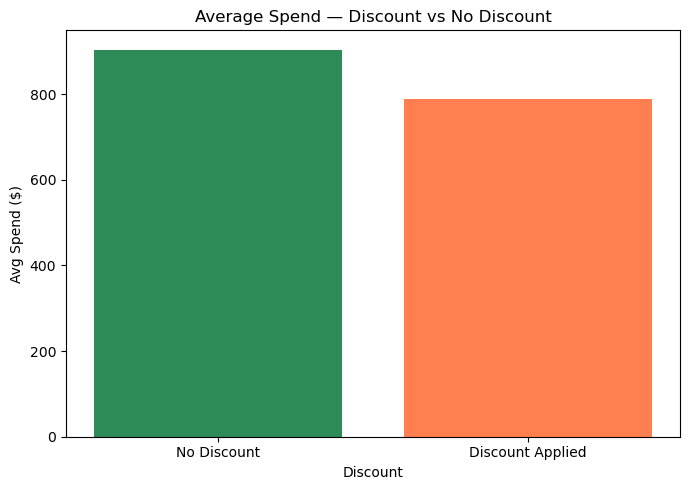

In [7]:
discount_spend = df.groupby("Discount Applied")["Total Spend"].mean().reset_index()
discount_spend["Discount Applied"] = discount_spend["Discount Applied"].map({True: "Discount Applied", False: "No Discount"})

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(discount_spend["Discount Applied"], discount_spend["Total Spend"], color=["seagreen", "coral"])
ax.set(title="Average Spend — Discount vs No Discount", xlabel="Discount", ylabel="Avg Spend ($)")
plt.tight_layout()
plt.savefig(r"C:\Users\deepj\Documents\statistical-analysis-hypothesis-testing\reports\discount_impact.png")
plt.show()